In [22]:
import sys
sys.path.insert(0, '/grid_mnt/data_cms_upgrade/biriukov/Validation-of-superclustering-DNN/python')

import pandas as pd
import numpy as np
import awkward as ak
from validation.sclsDataProcessing import *

import uproot as ur

tfile = ur.open('/grid_mnt/data_cms_upgrade/biriukov/data/singleElectrons_D110/step3/15_1_0_pre2/dumper/dumper_87.root')
df = pd.read_csv('/grid_mnt/data_cms_upgrade/biriukov/Validation-of-superclustering-DNN/scls_csv/best_associated.csv')

In [18]:
s2r_s = tfile['ticlDumper/associations/ticlTracksterLinksSuperclusteringDNN_simToReco_CP_score'].array()
s2r_id = tfile['ticlDumper/associations/ticlTracksterLinksSuperclusteringDNN_simToReco_CP'].array()
raw_energy = tfile['ticlDumper/ticlTracksterLinksSuperclusteringDNN/raw_energy'].array()

s2r_map = s2r_s < 0.2
s2r_id = fillNan(s2r_id[s2r_map])

In [23]:
df

,simToReco_id,simToReco_score,event,n_scls_per_cp,n_tr_per_scls,reco_raw_energy,reco_regressed_energy,reco_raw_pt,reco_barycenter_eta,reco_barycenter_phi,...,recoToSim_score,recoToSim_id,delta_barycenter_eta,delta_barycenter_phi,delta_barycenter_x,delta_barycenter_y,delta_barycenter_z,raw_energy_ratio,regressed_energy_ratio,file
0,0.0,0.001894,1.0,1,16.0,941.019226,0.0,179.808044,2.546271,2.926119,...,0.002861,0.0,0.002799,-0.007836,0.217674,0.376310,-0.100128,1.087493,0.0,0
1,5.0,0.000808,1.0,1,12.0,858.772888,0.0,157.543076,2.579684,-0.203292,...,0.002808,1.0,0.004184,0.000284,-0.181412,0.052408,0.201050,1.024133,0.0,0
2,2.0,0.001844,2.0,1,6.0,249.224167,0.0,234.760147,1.993195,0.687793,...,0.002445,0.0,-0.003478,-0.012935,0.991356,-0.731422,0.143921,0.997825,0.0,0
3,42.0,0.006253,2.0,1,1.0,219.021469,0.0,59.799171,1.968387,-2.420600,...,0.000304,1.0,-0.001750,0.004732,0.274704,-0.358707,-0.505737,0.883463,0.0,0
4,NaN,NaN,3.0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,0.0,0.000293,51.0,1,5.0,820.213562,0.0,142.531494,2.223850,0.626518,...,0.000385,0.0,0.001893,0.000213,-0.165474,-0.100384,0.230560,0.978971,0.0,31
6301,3.0,0.000404,51.0,1,7.0,806.220703,0.0,164.155228,2.248945,-2.515830,...,0.000336,1.0,0.001513,-0.005352,-0.102364,0.399658,-0.193329,0.965773,0.0,31
6302,12.0,0.002723,52.0,1,1.0,208.588440,0.0,42.630047,2.207351,2.167840,...,0.000327,0.0,-0.008970,-0.004703,-0.000591,0.616814,0.763428,0.875011,0.0,31
6303,2.0,0.001319,52.0,1,5.0,234.079208,0.0,77.819298,2.237985,-0.942811,...,0.001772,1.0,0.004646,0.010277,0.358032,0.781208,-0.371613,0.984570,0.0,31


In [19]:
ak.flatten(ak.broadcast_arrays(ak.Array(np.linspace(1, len(s2r_id), len(s2r_id))), raw_energy)[0], axis=None)

<Array [1, 1, 1, 1, 1, 1, ..., 100, 100, 100, 100, 100] type='4670 * float64'>

/tmp/ipykernel_2934825/272892570.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  ax.hist(np.array(ak.flatten(br_raw_energy, axis=None)), edges)


(array([ 0.,  0.,  1.,  4.,  0.,  4.,  3.,  6.,  5.,  3.,  7.,  6.,  9.,
        10., 24., 15., 19., 18., 39., 21.]),
 array([  16.36219978,   20.18520164,   24.90144157,   30.71961594,
          37.8972168 ,   46.75182724,   57.67532349,   71.15106964,
          87.77540588,  108.28399658,  133.58441162,  164.79615784,
         203.30046082,  250.80122375,  309.40060425,  381.69171143,
         470.8732605 ,  580.89190674,  716.61657715,  884.05316162,
        1090.61035156]),
 <BarContainer object of 20 artists>)

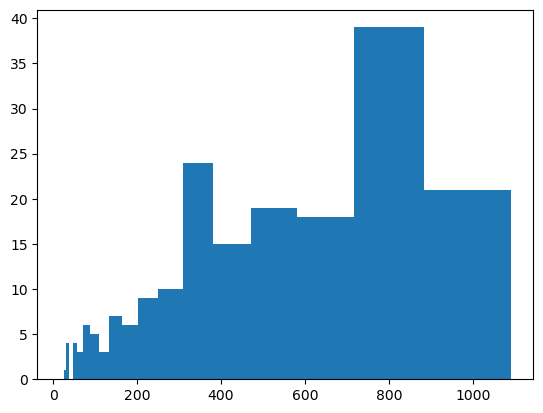

In [12]:
import matplotlib.pyplot as plt

edges = np.logspace(np.log10(np.min(br_raw_energy)), np.log10(np.max(br_raw_energy)), 21)

fig, ax = plt.subplots()
ax.hist(np.array(ak.flatten(br_raw_energy, axis=None)), edges)